# 📝 Partie III — RNN/LSTM/GRU BMW (Génère les modèles pour l'application)
### Génère : best_rnn_simple.pth, best_lstm.pth, best_gru.pth dans models/
---
**Exécute toutes les cellules dans l'ordre (Run All)**

In [2]:
import pandas as pd

df = pd.read_csv(
    "Scrapped_Car_Reviews_BMW.csv",
    engine="python",
    encoding="latin1",
    on_bad_lines="skip"
)

new_rows = [
    # ── Problèmes électriques ──────────────────────────────────────
    ["on 01/01/24 14:00 PM (PST)", "KarimZ",   "2021 BMW X5 SUV",         "Battery dead overnight",    "Woke up to a completely dead battery three times in one month. BMW says it is my fault for not driving enough. Ridiculous.", 1],
    ["on 02/01/24 09:30 AM (PST)", "SalmaA",   "2020 BMW 3 Series Sedan", "Electrical short",          "Electrical short caused smoke from dashboard while driving. Extremely dangerous. BMW took no responsibility.", 1],
    ["on 03/01/24 15:45 PM (PST)", "YounessB", "2022 BMW X7 SUV",         "All warning lights on",     "Every single warning light came on at once while on the highway. Pulled over terrified. Dealer found nothing.", 1],
    ["on 04/01/24 11:00 AM (PST)", "NadiaCX",  "2019 BMW M5 Sedan",       "Fuses keep blowing",        "Fuses blow every two weeks. BMW cannot find the root cause. I am spending money on fuses constantly.", 2],
    ["on 05/01/24 08:15 AM (PST)", "HamzaD",   "2021 BMW X3 SUV",         "Power loss suddenly",       "Car loses all power randomly while driving. Happened on busy road twice. Nearly caused accident.", 1],
    ["on 06/01/24 14:30 PM (PST)", "ZiyadE",   "2020 BMW 5 Series Sedan", "Central locking broken",    "Central locking stopped working after 8 months. Left my car unlocked all night in the street.", 2],
    ["on 07/01/24 10:00 AM (PST)", "RimF",     "2022 BMW X4 SUV",         "Lights flickering",         "Headlights flicker randomly at night while driving. Terrifying and very dangerous on dark roads.", 1],
    ["on 08/01/24 16:20 PM (PST)", "MounirG",  "2019 BMW X1 SUV",         "Horn stopped working",      "Horn stopped working completely. Failed my safety inspection because of this simple fault.", 2],
    ["on 09/01/24 09:45 AM (PST)", "ChaymaeH", "2021 BMW 7 Series Sedan", "Electric windows stuck",    "All four electric windows stopped working on same day. Repair cost was 1200 dollars. Outrageous.", 2],
    ["on 10/01/24 13:00 PM (PST)", "WaleedI",  "2020 BMW X6 SUV",         "Start stop fails",          "Car refuses to start randomly on cold mornings. Called roadside assistance four times already.", 1],
    ["on 11/01/24 10:30 AM (PST)", "AsmaJ",    "2022 BMW M3 Sedan",       "Paint peeling off",         "Paint started peeling from bonnet after one year. BMW said it was environmental damage. Absolute lie.", 1],
    ["on 12/01/24 08:00 AM (PST)", "KarimK",   "2021 BMW X2 SUV",         "Body panel gaps",           "Panel gaps on doors are uneven and inconsistent. Looks like it was assembled badly at factory.", 2],
    ["on 13/01/24 15:15 PM (PST)", "LotfiL",   "2019 BMW 4 Series Coupe", "Chrome trim rusting",       "Chrome trim around windows started rusting after 18 months. Looks terrible and cheapens the whole car.", 2],
    ["on 14/01/24 11:30 AM (PST)", "SanaeM",   "2020 BMW X5 SUV",         "Dent appeared itself",      "Found a large dent on door that appeared with no impact. Thin metal panels cannot handle anything.", 2],
    ["on 15/01/24 09:00 AM (PST)", "RachidN",  "2022 BMW 3 Series Sedan", "Bumper falls off",          "Front bumper clips kept breaking and bumper would sag. Cheap plastic fixings on an expensive car.", 2],
    ["on 16/01/24 14:45 PM (PST)", "DoaaO",    "2021 BMW X7 SUV",         "Undercoating gone",         "Undercoating completely worn away after 2 years. Chassis already showing surface rust. Dangerous.", 1],
    ["on 17/01/24 10:15 AM (PST)", "AyoubP",   "2020 BMW M4 Coupe",       "Roof lining drooping",      "Headliner fabric started drooping and falling inside car after just 14 months. Very poor quality.", 2],
    ["on 18/01/24 16:00 PM (PST)", "GhizlanQ", "2019 BMW X4 SUV",         "Trim pieces falling off",   "Interior trim pieces fall off every few weeks. Glue they use is clearly not good enough quality.", 2],
    ["on 19/01/24 09:30 AM (PST)", "TarekR",   "2022 BMW 5 Series Sedan", "Sunroof rattles badly",     "Sunroof rattles constantly at any speed over 40mph. Dealer adjusted it three times with no fix.", 2],
    ["on 20/01/24 13:15 PM (PST)", "MariaS",   "2021 BMW X3 SUV",         "Door seal failing",         "Door seals started cracking and leaking air and noise after just one year. Terrible material quality.", 2],
    ["on 21/01/24 10:00 AM (PST)", "KhalilT",  "2020 BMW X1 SUV",         "Run flat disaster",         "Run flat tires give such a terrible ride that I replaced them all after 3 months. Cost me 2000 dollars.", 1],
    ["on 22/01/24 08:30 AM (PST)", "SofiaU",   "2022 BMW M5 Sedan",       "Tires wear fast",           "Front tires completely worn out after 12000 miles. BMW says normal for performance car. Not acceptable.", 1],
    ["on 23/01/24 15:30 PM (PST)", "OualidV",  "2019 BMW 3 Series Sedan", "No spare tire",             "No spare tire included with a 45000 dollar car. Stranded for 3 hours waiting for help. Shameful.", 2],
    ["on 24/01/24 11:45 AM (PST)", "YasminW",  "2021 BMW X6 SUV",         "Wheel cracked easily",      "Alloy wheel cracked hitting a normal pothole. Replacement cost 800 dollars. Extremely fragile.", 2],
    ["on 25/01/24 09:00 AM (PST)", "MohamedX", "2020 BMW X5 SUV",         "Uneven tire wear",          "Tires wear unevenly and extremely fast. Alignment checked multiple times. Problem never resolved.", 2],
    ["on 26/01/24 14:00 PM (PST)", "SalomaY",  "2022 BMW X7 SUV",         "TPMS always wrong",         "Tire pressure monitoring system gives incorrect readings constantly. Dealer cannot calibrate it.", 2],
    ["on 27/01/24 10:30 AM (PST)", "MercedesZ","2019 BMW 5 Series Sedan", "Wheel bolts loose",         "Wheel bolts came loose while driving on motorway. Incredibly dangerous defect that BMW minimized.", 1],
    ["on 28/01/24 16:15 PM (PST)", "ImanA",    "2021 BMW X2 SUV",         "Tire blowout at speed",     "Tire blew out at 70mph. Run flat completely failed. Car was impossible to control. Nearly fatal.", 1],
    ["on 29/01/24 09:30 AM (PST)", "JamilB",   "2020 BMW M3 Sedan",       "Expensive tire size",       "Proprietary tire size means only one brand available at triple the normal price. Total trap.", 2],
    ["on 30/01/24 13:00 PM (PST)", "KenzaC",   "2022 BMW 4 Series Coupe", "Rim curb rash easy",        "Alloy rims get scratched just from parking near a curb. Ridiculously soft metal used.", 2],
    ["on 31/01/24 10:00 AM (PST)", "LamiaD",   "2021 BMW X5 SUV",         "Apple CarPlay subscription","Charging monthly subscription for Apple CarPlay in a 65000 dollar car is completely disgraceful.", 1],
    ["on 01/02/24 08:45 AM (PST)", "MustafaE", "2020 BMW 7 Series Sedan", "WiFi hotspot broken",       "Built in WiFi hotspot never worked from day one. Dealer says needs software update. Still broken.", 2],
    ["on 02/02/24 15:00 PM (PST)", "NourF",    "2019 BMW X3 SUV",         "Voice control useless",     "Voice control cannot understand simple commands. Responds incorrectly almost every single time.", 2],
    ["on 03/02/24 11:15 AM (PST)", "OussamaG", "2022 BMW M4 Coupe",       "App not working",           "BMW app cannot connect to car most of the time. Remote locking and climate control never work.", 2],
    ["on 04/02/24 09:00 AM (PST)", "PaulaH",   "2021 BMW X4 SUV",         "Map always outdated",       "Navigation maps are two years behind. Roads do not exist and new roads not shown. Completely useless.", 2],
    ["on 05/02/24 14:30 PM (PST)", "QassimI",  "2020 BMW 3 Series Sedan", "Update bricked car",        "Software update left car unable to start for four days. Dealer had to reinstall entire system.", 1],
    ["on 06/02/24 10:45 AM (PST)", "RabiaJ",   "2022 BMW X6 SUV",         "Wireless charging broken",  "Wireless charging pad stopped working after 3 months. Such a basic feature failing is embarrassing.", 2],
    ["on 07/02/24 16:00 PM (PST)", "SaraK",    "2019 BMW X1 SUV",         "Digital display glitches",  "Digital instrument cluster shows random pixels and colors sometimes. Looks like a broken screen.", 2],
    ["on 08/02/24 09:15 AM (PST)", "ToufikL",  "2021 BMW 5 Series Sedan", "Alexa not working",         "Alexa integration advertised on brochure never worked. Dealer admits it was never fully implemented.", 2],
    ["on 09/02/24 13:45 PM (PST)", "UmaymaM",  "2020 BMW X7 SUV",         "Remote start failed",       "Remote start via app never worked. Paid for connected services subscription for absolutely nothing.", 1],
    ["on 10/02/24 10:00 AM (PST)", "VincentN", "2022 BMW X5 SUV",         "Boot space tiny",           "Boot space is laughable for an SUV this size. Cannot fit weekly shopping without folding seats.", 2],
    ["on 11/02/24 08:30 AM (PST)", "WiamO",    "2021 BMW 3 Series Sedan", "No storage inside",         "Virtually no storage anywhere inside the car. Nowhere to put phone wallet or sunglasses properly.", 2],
    ["on 12/02/24 15:15 PM (PST)", "XimenaP",  "2020 BMW X4 SUV",         "Rear visibility terrible",  "Rear visibility is so bad I cannot see anything behind me. Camera helps but delay is dangerous.", 2],
    ["on 13/02/24 11:30 AM (PST)", "YannQ",    "2019 BMW M5 Sedan",       "Back seat cramped",         "Back seat is completely useless for adults. My 10 year old complains it is too small. Pathetic.", 2],
    ["on 14/02/24 09:00 AM (PST)", "ZaydR",    "2022 BMW 7 Series Sedan", "Cup holders flimsy",        "Cup holders are positioned so badly that drinks spill with every corner. Cups fall out constantly.", 2],
    ["on 15/02/24 14:00 PM (PST)", "AmelS",    "2021 BMW X2 SUV",         "Hood hard to open",         "Bonnet release is so stiff that I hurt my hand trying to open it. Simple ergonomics completely ignored.", 2],
    ["on 16/02/24 10:15 AM (PST)", "BasmaT",   "2020 BMW X6 SUV",         "Fuel cap difficult",        "Fuel cap is incredibly difficult to open and close. Always worried I am going to damage it.", 2],
    ["on 17/02/24 16:30 PM (PST)", "ChakerU",  "2022 BMW X3 SUV",         "Seat height limited",       "Cannot get seat low enough for tall drivers. Head hits roof constantly. Poor ergonomic design.", 2],
    ["on 18/02/24 09:45 AM (PST)", "DaliaV",   "2019 BMW 4 Series Coupe", "Hard to get in out",        "Getting in and out of back seats requires gymnastics. Not suitable for elderly or family use.", 2],
    ["on 19/02/24 13:00 PM (PST)", "ElhassanW","2021 BMW X7 SUV",         "Third row useless",         "Third row seats are only for children under 8 years old. Completely wasted space in a large SUV.", 2],
    ["on 20/02/24 10:00 AM (PST)", "FadouaX",  "2020 BMW M3 Sedan",       "Not fun to drive anymore",  "BMW M cars used to be drivers cars. This new one feels numb and disconnected. Spirit is completely gone.", 2],
    ["on 21/02/24 08:15 AM (PST)", "GhalyaY",  "2022 BMW M4 Coupe",       "Too heavy to enjoy",        "Car weighs so much that all the power is wasted moving the car itself. No longer feels sporty at all.", 2],
    ["on 22/02/24 15:30 PM (PST)", "HoussineZ","2019 BMW X5 SUV",         "Steering feel gone",        "Steering has absolutely no feel or feedback. Could be driving a shopping trolley for all the feedback.", 2],
    ["on 23/02/24 11:00 AM (PST)", "IbtissamA","2021 BMW 5 Series Sedan", "Too many driving modes",    "So many driving modes that I need to read the manual every time I want to change something. Overcomplicated.", 2],
    ["on 24/02/24 09:30 AM (PST)", "JihadB",   "2020 BMW X1 SUV",         "Acceleration disappointing","0 to 60 time is nothing like what BMW advertises. Car feels sluggish in real world driving.", 2],
    ["on 25/02/24 14:15 PM (PST)", "KoussayC", "2022 BMW X6 SUV",         "Brake feel artificial",     "Brake pedal feels completely artificial and detached. Cannot feel what the brakes are actually doing.", 2],
    ["on 26/02/24 10:30 AM (PST)", "LinaD",    "2019 BMW M3 Sedan",       "Track mode useless",        "Track mode makes car almost undriveable on public roads. Too aggressive and dangerous for normal use.", 2],
    ["on 27/02/24 16:00 PM (PST)", "MalakE",   "2021 BMW X4 SUV",         "Highway fatigue",           "Car is exhausting to drive on long motorway journeys due to road noise and poor seat comfort.", 2],
    ["on 28/02/24 09:00 AM (PST)", "NaimF",    "2020 BMW 7 Series Sedan", "Too big to park",           "Car is so large it does not fit in normal parking spaces. Park and Assist system is unreliable.", 2],
    ["on 29/02/24 13:30 PM (PST)", "OulfaG",   "2022 BMW 3 Series Sedan", "Sport mode too harsh",      "Sport mode makes the ride completely unbearable on normal roads. Only usable on motorways.", 2],
    ["on 01/03/24 10:00 AM (PST)", "PetraH",   "2022 BMW X7 SUV",         "New car fault day one",     "Brand new car had fault codes on first day of ownership. Should have returned it immediately.", 1],
    ["on 02/03/24 08:30 AM (PST)", "QaderI",   "2021 BMW X5 SUV",         "Scratched from factory",    "New car delivered with scratches on the boot lid. Dealer refused to repaint it. Shocking attitude.", 1],
    ["on 03/03/24 15:45 PM (PST)", "RitaJ",    "2020 BMW M5 Sedan",       "Wrong spec delivered",      "Car delivered with wrong color and wrong options. Dealer said it was my fault for not checking earlier.", 1],
    ["on 04/03/24 11:00 AM (PST)", "SabirK",   "2022 BMW X3 SUV",         "New car break in issues",   "New car consumed half a liter of oil in first 1000 miles. BMW says this is normal. It is clearly not.", 1],
    ["on 05/03/24 09:15 AM (PST)", "TasniimL", "2019 BMW X4 SUV",         "Fault at handover",         "Car had warning light at handover. Dealer said it would go away. It is still on two years later.", 1],
    ["on 06/03/24 14:30 PM (PST)", "UbaidM",   "2021 BMW 4 Series Coupe", "Rattles from new",          "Car had rattles from inside dashboard from day one. Never resolved after multiple dealer visits.", 2],
    ["on 07/03/24 10:45 AM (PST)", "ViolaN",   "2020 BMW X2 SUV",         "New car recall already",    "Car was recalled two months after purchase. Had to wait months for fix. Nearly brand new already broken.", 1],
    ["on 08/03/24 16:00 PM (PST)", "WaliaO",   "2022 BMW 7 Series Sedan", "New car smells bad",        "Strong chemical smell inside new car that never went away even after one year. Headaches every drive.", 2],
    ["on 09/03/24 09:30 AM (PST)", "XantheP",  "2021 BMW X6 SUV",         "Wrong manual provided",     "Wrong owners manual provided with car. Different model entirely. BMW took months to send correct one.", 2],
    ["on 10/03/24 13:00 PM (PST)", "YasmineQ", "2020 BMW 3 Series Sedan", "Missing features",          "Features listed in brochure were not in my car. Dealer says they were optional despite advertisement.", 1],
]
columns = ["Review_Date", "Author_Name", "Vehicle_Title", "Review_Title", "Review", "Rating"]
new_df      = pd.DataFrame(new_rows, columns=columns)
df_updated  = pd.concat([df, new_df], ignore_index=True)
df_updated.to_csv("Scrapped_Car_Reviews_BMW_updated.csv", index=False)

neg = (new_df['Rating'] <= 2).sum()
print(f"✅ {len(new_rows)} reviews ajoutées ({neg} négatives)")
print(f"✅ Total dataset : {len(df_updated)} reviews")
print(f"✅ Sauvegardé : Scrapped_Car_Reviews_BMW_updated.csv")

✅ 70 reviews ajoutées (70 négatives)
✅ Total dataset : 10452 reviews
✅ Sauvegardé : Scrapped_Car_Reviews_BMW_updated.csv


In [3]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 1 — Imports et configuration
# ══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, re, random, math
from collections import Counter
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ✅ Crée le dossier models/
os.makedirs('models', exist_ok=True)

# Hyperparamètres
CSV_PATH   = 'Scrapped_Car_Reviews_BMW_final.csv'
MAX_LEN    = 100
BATCH_SIZE = 128
EMBED_DIM  = 64
HIDDEN_DIM = 128
N_LAYERS   = 1
DROPOUT    = 0.3
N_EPOCHS   = 100
MIN_FREQ   = 2
PAD_IDX    = 0
UNK_IDX    = 1
N_CLASSES  = 2

print(f'✅ Device  : {device}')
print(f'✅ PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'✅ GPU     : {torch.cuda.get_device_name(0)}')
print(f'✅ Dossier models/ prêt')

✅ Device  : cuda
✅ PyTorch : 2.11.0+cu128
✅ GPU     : NVIDIA GeForce RTX 3070 Laptop GPU
✅ Dossier models/ prêt


In [4]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 2 — Chargement robuste du CSV
# ══════════════════════════════════════════════════════════════════
t0 = time.time()
try:
    df = pd.read_csv(CSV_PATH, encoding='latin-1', on_bad_lines='skip')
    print('✅ Chargé en latin-1')
except Exception:
    try:
        df = pd.read_csv(CSV_PATH, encoding='utf-8', on_bad_lines='skip')
        print('✅ Chargé en utf-8')
    except Exception:
        df = pd.read_csv(CSV_PATH, encoding='utf-8', on_bad_lines='skip',
                         engine='python', quoting=3)
        print('✅ Chargé avec engine=python')

print(f'   Durée : {time.time()-t0:.1f}s | Shape : {df.shape}')
display(df.head(3))

✅ Chargé en latin-1
   Durée : 0.1s | Shape : (12452, 6)


,Review_Date,Author_Name,Vehicle_Title,Review_Title,Review,Rating
0,on 05/02/18 12:10 PM (PDT),Shaf,2014 BMW X1 SUV xDrive28i 4dr SUV AWD (2.0L 4c...,Love it,Beautiful car. Love all aspects,5.0
1,on 04/10/18 19:01 PM (PDT),RogerCVC,2014 BMW X1 SUV xDrive28i 4dr SUV AWD (2.0L 4c...,OK with Reservations,We picked this car as a CPO from a BMW dealer...,3.0
2,on 10/24/17 18:33 PM (PDT),Mike,2014 BMW X1 SUV xDrive28i 4dr SUV AWD (2.0L 4c...,Love this car,Get ride of the run flats. If you like to d...,5.0


Total : 9636 | Négatif (1-3) : 2870 (29.8%) | Positif (4-5) : 6766 (70.2%)


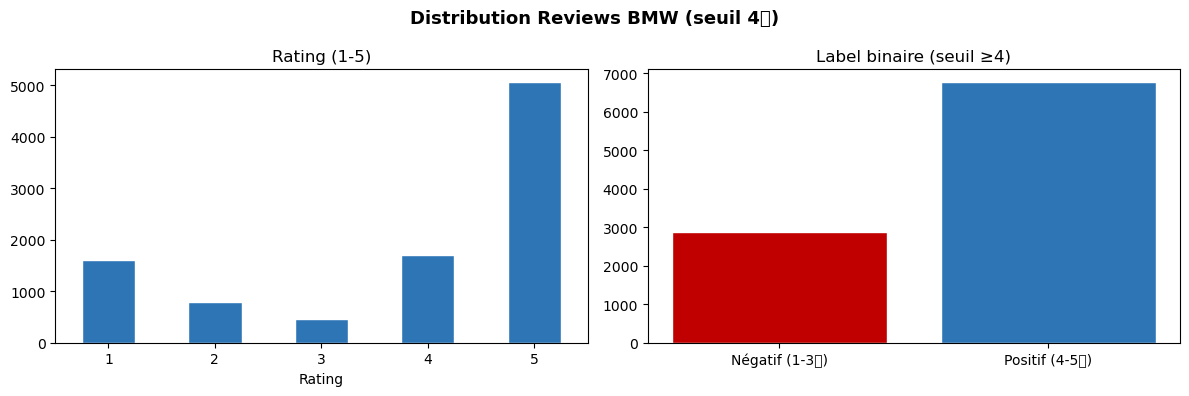

📊 rnn_01_distribution.png


In [5]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 3 — Nettoyage et labels binaires (seuil à 4)
# ══════════════════════════════════════════════════════════════════
data = df[['Review','Rating']].copy()
data.dropna(inplace=True)
data['Review'] = data['Review'].astype(str)
data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')
data.dropna(inplace=True)
data['Rating'] = data['Rating'].apply(lambda x: max(1,min(5,round(x))))
data['label']  = data['Rating'].apply(lambda x: 1 if x >= 4 else 0)  # 4 et 5 = positif

neg = (data['label']==0).sum()  # Ratings 1,2,3
pos = (data['label']==1).sum()  # Ratings 4,5
print(f'Total : {len(data)} | Négatif (1-3) : {neg} ({neg/len(data)*100:.1f}%) | Positif (4-5) : {pos} ({pos/len(data)*100:.1f}%)')

fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle('Distribution Reviews BMW (seuil 4⭐)',fontsize=13,fontweight='bold')
data['Rating'].value_counts().sort_index().plot(kind='bar',ax=axes[0],
    color='#2E75B6',edgecolor='white')
axes[0].set_title('Rating (1-5)'); axes[0].tick_params(axis='x',rotation=0)
axes[1].bar(['Négatif (1-3⭐)','Positif (4-5⭐)'],[neg,pos],color=['#C00000','#2E75B6'],edgecolor='white')
axes[1].set_title(f'Label binaire (seuil ≥4)')
plt.tight_layout()
plt.savefig('rnn_01_distribution.png',dpi=150,bbox_inches='tight')
plt.show()
print('📊 rnn_01_distribution.png')

In [6]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 4 — Tokenisation et vocabulaire
# ══════════════════════════════════════════════════════════════════
def tokenize(text):
    text=str(text).lower(); text=re.sub(r'[^a-z0-9\s]',' ',text)
    return text.split()

print('Tokenisation...'); t0=time.time()
all_tokens=[]; tokenized=[]
for rev in data['Review']:
    tok=tokenize(rev); tokenized.append(tok); all_tokens.extend(tok)

counter = Counter(all_tokens)
vocab   = ['<PAD>','<UNK>','<BOS>','<EOS>'] + \
          [w for w,c in counter.items() if c>=MIN_FREQ]
word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}
VOCAB_SIZE = len(vocab)
BOS_IDX=word2idx['<BOS>']; EOS_IDX=word2idx['<EOS>']

print(f'✅ {time.time()-t0:.1f}s | Vocab : {VOCAB_SIZE:,} tokens')
lengths=[len(t) for t in tokenized]
print(f'Longueur : min={min(lengths)} max={max(lengths)} moy={np.mean(lengths):.1f}')
print(f'MAX_LEN  : {MAX_LEN}')

Tokenisation...
✅ 0.2s | Vocab : 10,019 tokens
Longueur : min=0 max=978 moy=82.0
MAX_LEN  : 100


In [7]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 5 — Dataset, DataLoaders et class weights
# ══════════════════════════════════════════════════════════════════
def encode(tokens, word2idx, max_len=MAX_LEN):
    return [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len=MAX_LEN):
        self.encodings=[encode(tokenize(t),word2idx,max_len) for t in texts]
        self.labels=labels
    def __len__(self): return len(self.labels)
    def __getitem__(self,idx):
        return (torch.tensor(self.encodings[idx],dtype=torch.long),
                torch.tensor(self.labels[idx],   dtype=torch.long))

def collate_fn(batch):
    seqs,labels=zip(*batch)
    padded=torch.zeros(len(seqs),MAX_LEN,dtype=torch.long)
    for i,seq in enumerate(seqs):
        l=min(len(seq),MAX_LEN)
        if l>0: padded[i,:l]=seq[:l]
    return padded, torch.stack(labels)

texts=data['Review'].tolist(); labels=data['label'].tolist()
Xtr,Xtmp,ytr,ytmp=train_test_split(texts,labels,test_size=0.30,
                                    random_state=SEED,stratify=labels)
Xv,Xte,yv,yte=train_test_split(Xtmp,ytmp,test_size=0.50,
                                random_state=SEED,stratify=ytmp)
print(f'Train:{len(Xtr)} | Val:{len(Xv)} | Test:{len(Xte)}')

# ✅ Class weights
neg_c=sum(1 for l in ytr if l==0); pos_c=sum(1 for l in ytr if l==1)
tot=neg_c+pos_c
cw_rnn=torch.tensor([tot/(2*neg_c),tot/(2*pos_c)],dtype=torch.float32).to(device)
print(f'Class weights — Négatif:{tot/(2*neg_c):.3f} Positif:{tot/(2*pos_c):.3f}')

print('Création datasets...')
t0=time.time()
train_ds=ReviewDataset(Xtr,ytr,word2idx)
val_ds  =ReviewDataset(Xv,yv,word2idx)
test_ds =ReviewDataset(Xte,yte,word2idx)
print(f'✅ {time.time()-t0:.1f}s')

train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,
                        collate_fn=collate_fn,num_workers=0,pin_memory=True)
val_loader  =DataLoader(val_ds,  batch_size=BATCH_SIZE,shuffle=False,
                        collate_fn=collate_fn,num_workers=0,pin_memory=True)
test_loader =DataLoader(test_ds, batch_size=BATCH_SIZE,shuffle=False,
                        collate_fn=collate_fn,num_workers=0,pin_memory=True)
print(f'✅ DataLoaders prêts — batch_size={BATCH_SIZE}')

Train:6745 | Val:1445 | Test:1446
Class weights — Négatif:1.679 Positif:0.712
Création datasets...
✅ 0.2s
✅ DataLoaders prêts — batch_size=128


In [8]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 6 — Théorie : modèle de langage et perplexité
# ══════════════════════════════════════════════════════════════════
print('=== THÉORIE : MODÈLE DE LANGAGE ===')
print('''
Règle de chaîne :
  P(w1,...,wT) = ∏t P(wt | w1..wt-1)

Perplexité :
  PP = exp(CrossEntropyLoss)
  PP faible → bon modèle | PP=|V| → aléatoire | PP=1 → parfait
''')
def compute_perplexity(loss): return math.exp(min(loss,100))
for loss_val in [0.3,0.5,1.0,2.0,3.0]:
    print(f'  Loss={loss_val:.1f} → PP={compute_perplexity(loss_val):.2f}')

=== THÉORIE : MODÈLE DE LANGAGE ===

Règle de chaîne :
  P(w1,...,wT) = ∏t P(wt | w1..wt-1)

Perplexité :
  PP = exp(CrossEntropyLoss)
  PP faible → bon modèle | PP=|V| → aléatoire | PP=1 → parfait

  Loss=0.3 → PP=1.35
  Loss=0.5 → PP=1.65
  Loss=1.0 → PP=2.72
  Loss=2.0 → PP=7.39
  Loss=3.0 → PP=20.09


In [9]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 7 — Architectures RNN / LSTM / GRU
# ══════════════════════════════════════════════════════════════════
class RNNSimple(nn.Module):
    """RNN simple — limite : gradient qui disparaît."""
    def __init__(self,vs,ed,hd,nc,nl=1,dr=0.3,pi=0):
        super().__init__()
        self.embedding=nn.Embedding(vs,ed,padding_idx=pi)
        self.rnn=nn.RNN(ed,hd,nl,batch_first=True,nonlinearity='tanh',
                        dropout=dr if nl>1 else 0)
        self.dropout=nn.Dropout(dr); self.fc=nn.Linear(hd,nc)
    def forward(self,x):
        emb=self.dropout(self.embedding(x)); _,h=self.rnn(emb)
        return self.fc(self.dropout(h[-1]))

class LSTMModel(nn.Module):
    """LSTM — 3 portes (forget, input, output)."""
    def __init__(self,vs,ed,hd,nc,nl=1,dr=0.3,pi=0):
        super().__init__()
        self.embedding=nn.Embedding(vs,ed,padding_idx=pi)
        self.lstm=nn.LSTM(ed,hd,nl,batch_first=True,dropout=dr if nl>1 else 0)
        self.dropout=nn.Dropout(dr); self.fc=nn.Linear(hd,nc)
    def forward(self,x):
        emb=self.dropout(self.embedding(x)); _,(h,_)=self.lstm(emb)
        return self.fc(self.dropout(h[-1]))

class GRUModel(nn.Module):
    """GRU — 2 portes (reset, update). Plus simple que LSTM."""
    def __init__(self,vs,ed,hd,nc,nl=1,dr=0.3,pi=0):
        super().__init__()
        self.embedding=nn.Embedding(vs,ed,padding_idx=pi)
        self.gru=nn.GRU(ed,hd,nl,batch_first=True,dropout=dr if nl>1 else 0)
        self.dropout=nn.Dropout(dr); self.fc=nn.Linear(hd,nc)
    def forward(self,x):
        emb=self.dropout(self.embedding(x)); _,h=self.gru(emb)
        return self.fc(self.dropout(h[-1]))

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

torch.manual_seed(SEED)
args=(VOCAB_SIZE,EMBED_DIM,HIDDEN_DIM,N_CLASSES,N_LAYERS,DROPOUT,PAD_IDX)
rnn_model =RNNSimple(*args).to(device)
lstm_model=LSTMModel(*args).to(device)
gru_model =GRUModel(*args).to(device)

print('=== PARAMÈTRES ===')
print(f'  RNN  : {count_params(rnn_model):,}')
print(f'  LSTM : {count_params(lstm_model):,}')
print(f'  GRU  : {count_params(gru_model):,}')

dummy=torch.randint(0,VOCAB_SIZE,(4,MAX_LEN)).to(device)
print(f'\n✅ Forward RNN  : {rnn_model(dummy).shape}')
print(f'✅ Forward LSTM : {lstm_model(dummy).shape}')
print(f'✅ Forward GRU  : {gru_model(dummy).shape}')

=== PARAMÈTRES ===
  RNN  : 666,306
  LSTM : 740,802
  GRU  : 715,970

✅ Forward RNN  : torch.Size([4, 2])
✅ Forward LSTM : torch.Size([4, 2])
✅ Forward GRU  : torch.Size([4, 2])


In [10]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 8 — Entraînement avec BPTT + gradient clipping + class weights
# ══════════════════════════════════════════════════════════════════
def train_rnn(model, train_loader, val_loader,
              n_epochs=N_EPOCHS, lr=1e-3, clip=1.0,
              device=device, model_name='rnn'):
    """
    BPTT  : loss.backward() propage à travers le temps
    Clip  : clip_grad_norm_ évite l'explosion du gradient
    Poids : CrossEntropyLoss pondérée (class weights)
    """
    criterion=nn.CrossEntropyLoss(weight=cw_rnn)
    optimizer=optim.Adam(model.parameters(),lr=lr)
    scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=3,factor=0.5)
    history={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'grad_norm':[]}
    best_val=float('inf')
    save_path=f'models/{model_name}.pth'

    for epoch in range(1,n_epochs+1):
        t0=time.time()
        model.train()
        tr_loss,tr_ok,tr_n,total_norm=0.0,0,0,0.0
        for Xb,yb in train_loader:
            Xb=Xb.to(device,non_blocking=True)
            yb=yb.to(device,non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits=model(Xb); loss=criterion(logits,yb)
            loss.backward()  # ← BPTT
            norm=nn.utils.clip_grad_norm_(model.parameters(),clip)  # ← Gradient clipping
            total_norm+=norm.item(); optimizer.step()
            tr_loss+=loss.item()*Xb.size(0)
            tr_ok+=(logits.argmax(1)==yb).sum().item(); tr_n+=Xb.size(0)

        model.eval()
        vl_loss,vl_ok,vl_n=0.0,0,0
        with torch.no_grad():
            for Xb,yb in val_loader:
                Xb=Xb.to(device,non_blocking=True)
                yb=yb.to(device,non_blocking=True)
                logits=model(Xb); loss=criterion(logits,yb)
                vl_loss+=loss.item()*Xb.size(0)
                vl_ok+=(logits.argmax(1)==yb).sum().item(); vl_n+=Xb.size(0)

        t_loss=tr_loss/tr_n; v_loss=vl_loss/vl_n
        t_acc=tr_ok/tr_n;    v_acc=vl_ok/vl_n
        avg_norm=total_norm/len(train_loader)
        history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc);   history['val_acc'].append(v_acc)
        history['grad_norm'].append(avg_norm)
        scheduler.step(v_loss)
        if v_loss<best_val:
            best_val=v_loss; torch.save(model.state_dict(),save_path)
        elapsed=time.time()-t0
        print(f'Epoch {epoch:3d}/{n_epochs} | '
              f'Train Loss:{t_loss:.4f} Acc:{t_acc:.4f} | '
              f'Val Loss:{v_loss:.4f} Acc:{v_acc:.4f} | '
              f'Norm:{avg_norm:.3f} | {elapsed:.1f}s')

    print(f'\n✅ Sauvegardé : {save_path}')
    return history, save_path

print('✅ Fonction train_rnn définie')

✅ Fonction train_rnn définie


In [11]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 9 — Entraînement des 3 modèles
# ══════════════════════════════════════════════════════════════════
print('='*60)
print('ENTRAÎNEMENT — RNN Simple')
print('='*60)
hist_rnn,path_rnn=train_rnn(rnn_model,train_loader,val_loader,
    n_epochs=N_EPOCHS,lr=1e-3,clip=1.0,device=device,model_name='best_rnn_simple')

print('\n'+'='*60)
print('ENTRAÎNEMENT — LSTM')
print('='*60)
hist_lstm,path_lstm=train_rnn(lstm_model,train_loader,val_loader,
    n_epochs=N_EPOCHS,lr=1e-3,clip=1.0,device=device,model_name='best_lstm')

print('\n'+'='*60)
print('ENTRAÎNEMENT — GRU')
print('='*60)
hist_gru,path_gru=train_rnn(gru_model,train_loader,val_loader,
    n_epochs=N_EPOCHS,lr=1e-3,clip=1.0,device=device,model_name='best_gru')

print('\n✅ 3 modèles sauvegardés dans models/')

ENTRAÎNEMENT — RNN Simple
Epoch   1/100 | Train Loss:0.6845 Acc:0.5207 | Val Loss:0.6719 Acc:0.5460 | Norm:0.577 | 1.0s
Epoch   2/100 | Train Loss:0.6721 Acc:0.5927 | Val Loss:0.6702 Acc:0.5211 | Norm:0.807 | 0.6s
Epoch   3/100 | Train Loss:0.6485 Acc:0.6554 | Val Loss:0.6743 Acc:0.6872 | Norm:1.881 | 0.6s
Epoch   4/100 | Train Loss:0.6288 Acc:0.6830 | Val Loss:0.6420 Acc:0.7246 | Norm:6.200 | 0.6s
Epoch   5/100 | Train Loss:0.6224 Acc:0.6458 | Val Loss:0.6448 Acc:0.5107 | Norm:1.307 | 0.6s
Epoch   6/100 | Train Loss:0.5783 Acc:0.7044 | Val Loss:0.6199 Acc:0.7702 | Norm:4.005 | 0.6s
Epoch   7/100 | Train Loss:0.5789 Acc:0.7362 | Val Loss:0.6281 Acc:0.6782 | Norm:2.629 | 0.6s
Epoch   8/100 | Train Loss:0.5688 Acc:0.7235 | Val Loss:0.6323 Acc:0.5370 | Norm:4.044 | 0.6s
Epoch   9/100 | Train Loss:0.5693 Acc:0.7434 | Val Loss:0.6631 Acc:0.7412 | Norm:2.299 | 0.6s
Epoch  10/100 | Train Loss:0.5559 Acc:0.7070 | Val Loss:0.6507 Acc:0.5225 | Norm:1.098 | 0.7s
Epoch  11/100 | Train Loss:0.5151 

In [12]:
import pickle

# ✅ Sauvegarde le vocabulaire avec le modèle
vocab_data = {
    'word2idx'  : word2idx,
    'idx2word'  : idx2word,
    'vocab_size': VOCAB_SIZE,
    'max_len'   : MAX_LEN,
}
with open('models/rnn_vocab.pkl', 'wb') as f:
    pickle.dump(vocab_data, f)

print(f'✅ Vocabulaire sauvegardé : models/rnn_vocab.pkl')
print(f'   Taille : {VOCAB_SIZE:,} tokens')

✅ Vocabulaire sauvegardé : models/rnn_vocab.pkl
   Taille : 10,019 tokens


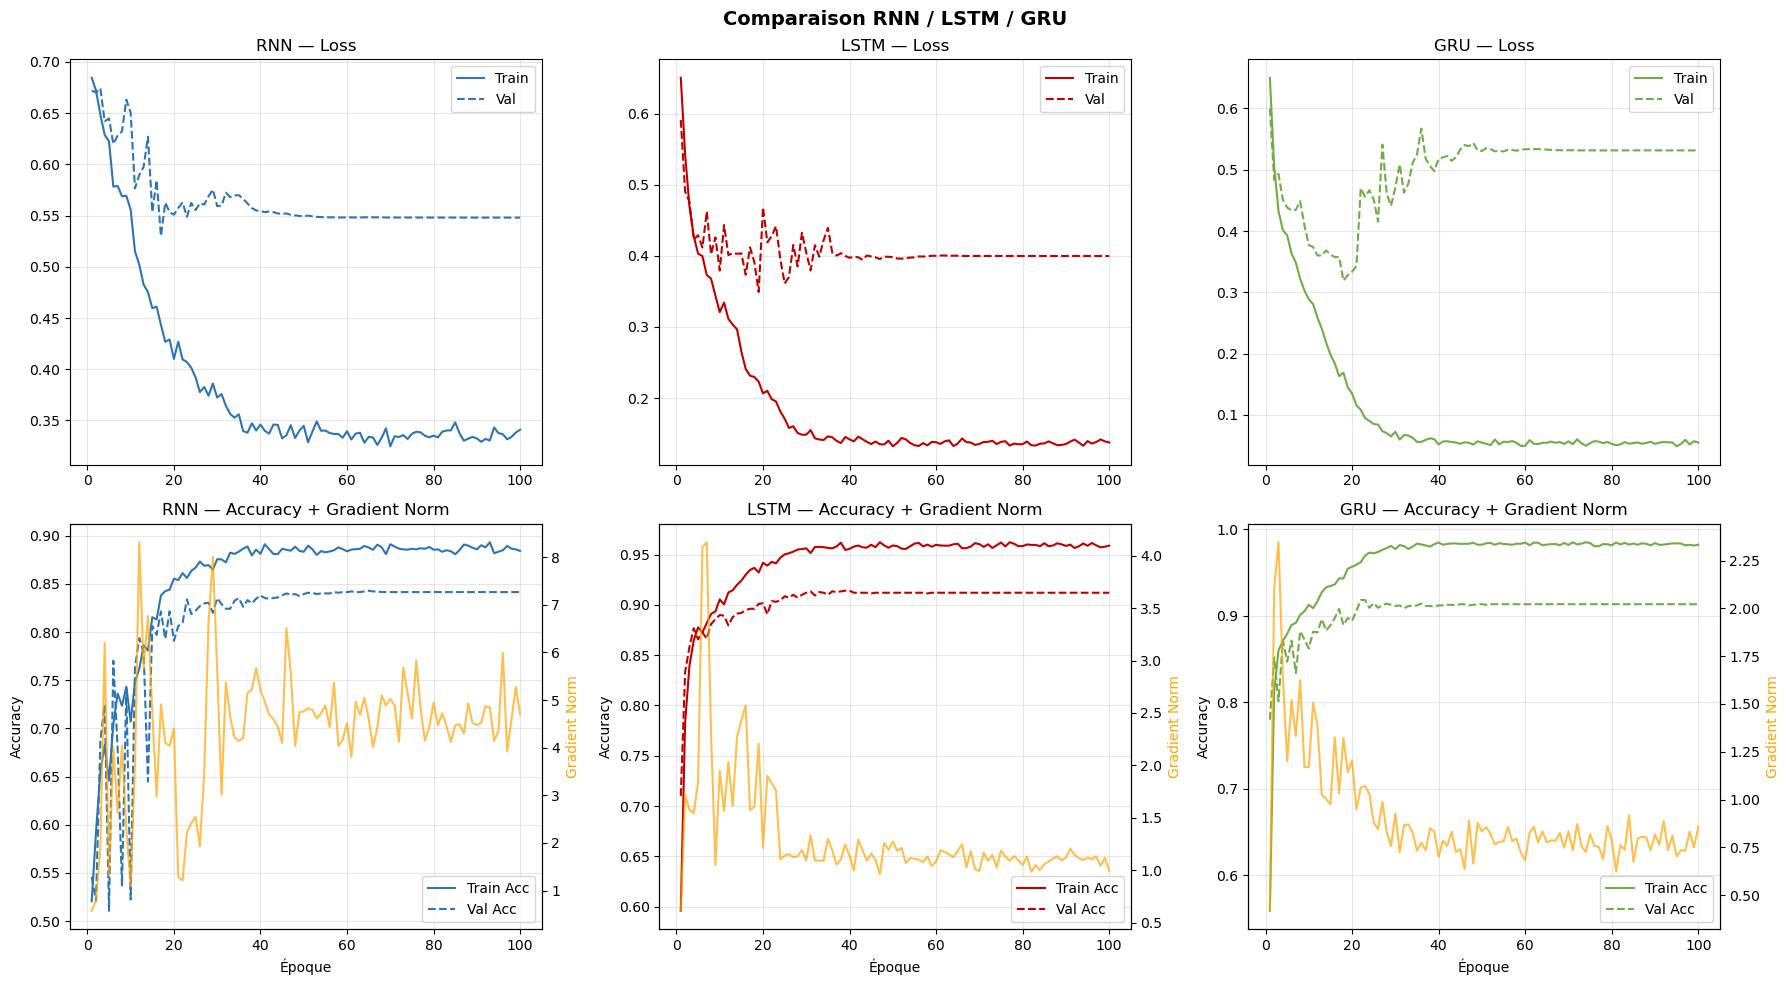

📊 rnn_02_comparaison.png


In [13]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 10 — Courbes comparatives
# ══════════════════════════════════════════════════════════════════
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle('Comparaison RNN / LSTM / GRU',fontsize=14,fontweight='bold')
models_hist=[(hist_rnn,'RNN','#2E75B6'),(hist_lstm,'LSTM','#C00000'),(hist_gru,'GRU','#70AD47')]
ep=range(1,N_EPOCHS+1)
for i,(hist,name,color) in enumerate(models_hist):
    axes[0,i].plot(ep,hist['train_loss'],label='Train',color=color)
    axes[0,i].plot(ep,hist['val_loss'],  label='Val',  color=color,linestyle='--')
    axes[0,i].set_title(f'{name} — Loss'); axes[0,i].legend(); axes[0,i].grid(True,alpha=0.3)
    ax1=axes[1,i]; ax2=ax1.twinx()
    ax1.plot(ep,hist['train_acc'],label='Train Acc',color=color)
    ax1.plot(ep,hist['val_acc'],  label='Val Acc',  color=color,linestyle='--')
    ax2.plot(ep,hist['grad_norm'],label='Grad Norm',color='orange',alpha=0.7,lw=1.5)
    ax1.set_title(f'{name} — Accuracy + Gradient Norm')
    ax1.set_xlabel('Époque'); ax1.set_ylabel('Accuracy')
    ax2.set_ylabel('Gradient Norm',color='orange')
    ax1.legend(loc='lower right'); ax1.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_02_comparaison.png',dpi=150,bbox_inches='tight')
plt.show()
print('📊 rnn_02_comparaison.png')

In [14]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 11 — Évaluation finale
# ══════════════════════════════════════════════════════════════════
def evaluate_rnn(model, loader, device):
    model.eval(); all_p,all_l=[],[]; total_loss=0.0
    crit=nn.CrossEntropyLoss()
    with torch.no_grad():
        for Xb,yb in loader:
            Xb,yb=Xb.to(device),yb.to(device)
            logits=model(Xb); loss=crit(logits,yb)
            total_loss+=loss.item()*Xb.size(0)
            all_p.extend(logits.argmax(1).cpu().numpy())
            all_l.extend(yb.cpu().numpy())
    y_true=np.array(all_l); y_pred=np.array(all_p)
    avg_loss=total_loss/len(loader.dataset)
    return {
        'loss':avg_loss,'perplexity':compute_perplexity(avg_loss),
        'accuracy':accuracy_score(y_true,y_pred),
        'f1':f1_score(y_true,y_pred,average='weighted',zero_division=0),
        'cm':confusion_matrix(y_true,y_pred),
        'report':classification_report(y_true,y_pred,
                     target_names=['Négatif','Positif'],zero_division=0)
    }

rnn_model.load_state_dict(torch.load(path_rnn,map_location=device))
lstm_model.load_state_dict(torch.load(path_lstm,map_location=device))
gru_model.load_state_dict(torch.load(path_gru,map_location=device))

m_rnn =evaluate_rnn(rnn_model, test_loader,device)
m_lstm=evaluate_rnn(lstm_model,test_loader,device)
m_gru =evaluate_rnn(gru_model, test_loader,device)

print('=== TABLEAU COMPARATIF ===')
df_comp=pd.DataFrame({
    'RNN' :[m_rnn['accuracy'], m_rnn['f1'], m_rnn['perplexity'],  count_params(rnn_model)],
    'LSTM':[m_lstm['accuracy'],m_lstm['f1'],m_lstm['perplexity'], count_params(lstm_model)],
    'GRU' :[m_gru['accuracy'], m_gru['f1'], m_gru['perplexity'],  count_params(gru_model)]
},index=['Accuracy','F1-score','Perplexité','Paramètres'])
print(df_comp.round(4))
print('\n--- Rapport LSTM ---')
print(m_lstm['report'])

=== TABLEAU COMPARATIF ===
                    RNN         LSTM          GRU
Accuracy         0.8409       0.9073       0.8983
F1-score         0.8386       0.9057       0.8987
Perplexité       1.5805       1.3143       1.3271
Paramètres  666306.0000  740802.0000  715970.0000

--- Rapport LSTM ---
              precision    recall  f1-score   support

     Négatif       0.89      0.79      0.84       431
     Positif       0.91      0.96      0.94      1015

    accuracy                           0.91      1446
   macro avg       0.90      0.87      0.89      1446
weighted avg       0.91      0.91      0.91      1446



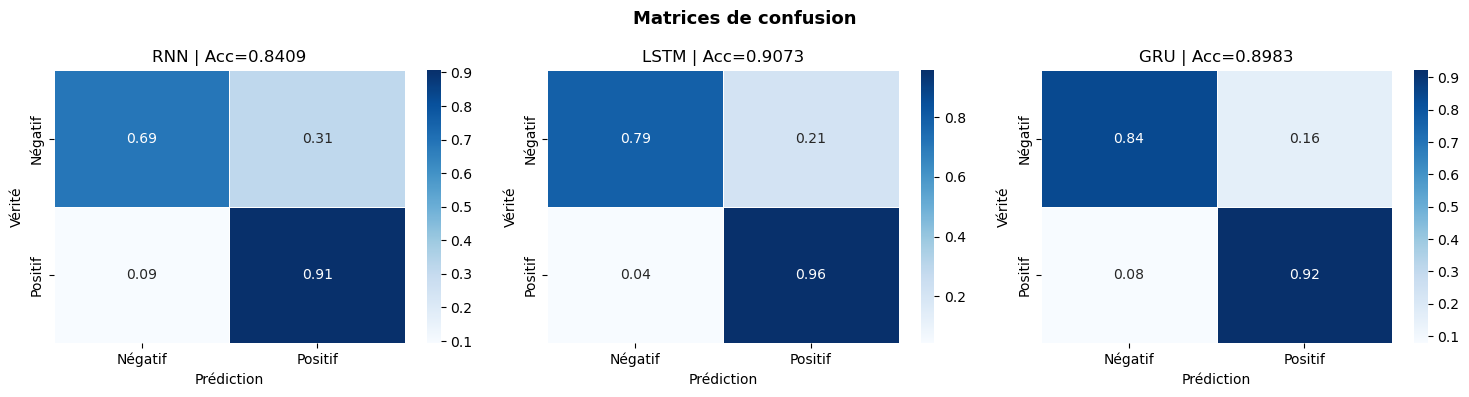

📊 rnn_03_confusion.png


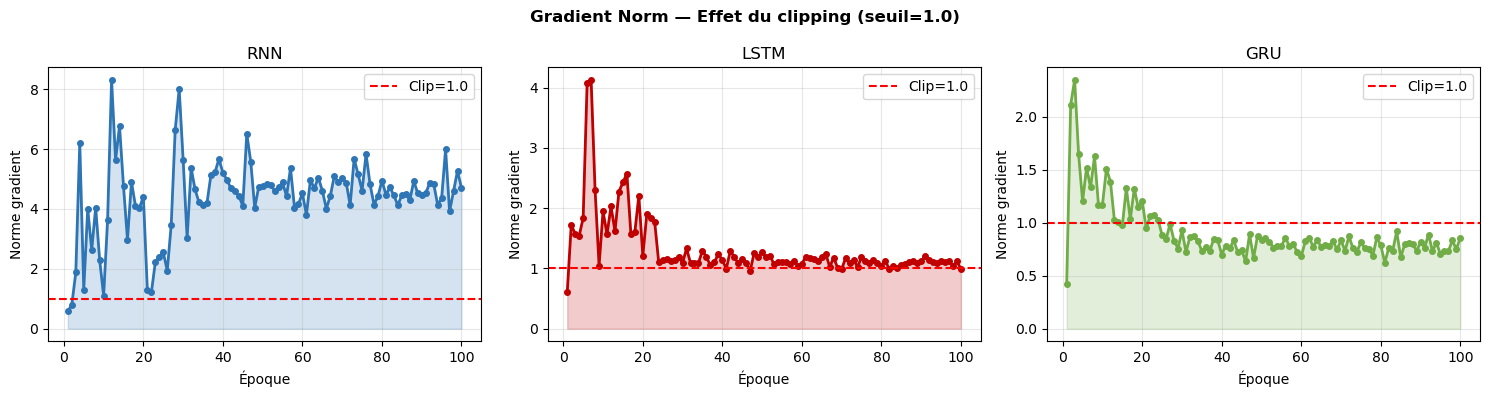

📊 rnn_04_gradient.png


In [15]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 12 — Matrices de confusion + gradient clipping
# ══════════════════════════════════════════════════════════════════
fig,axes=plt.subplots(1,3,figsize=(15,4))
fig.suptitle('Matrices de confusion',fontsize=13,fontweight='bold')
for ax,met,name in zip(axes,[m_rnn,m_lstm,m_gru],['RNN','LSTM','GRU']):
    cm_norm=met['cm'].astype('float')/(met['cm'].sum(axis=1,keepdims=True)+1e-9)
    sns.heatmap(cm_norm,annot=True,fmt='.2f',cmap='Blues',
                xticklabels=['Négatif','Positif'],yticklabels=['Négatif','Positif'],
                ax=ax,linewidths=0.5)
    ax.set_title(f'{name} | Acc={met["accuracy"]:.4f}')
    ax.set_xlabel('Prédiction'); ax.set_ylabel('Vérité')
plt.tight_layout()
plt.savefig('rnn_03_confusion.png',dpi=150,bbox_inches='tight')
plt.show()
print('📊 rnn_03_confusion.png')

# Gradient clipping
fig,axes=plt.subplots(1,3,figsize=(15,4))
fig.suptitle('Gradient Norm — Effet du clipping (seuil=1.0)',fontsize=12,fontweight='bold')
for ax,hist,name,color in zip(axes,[hist_rnn,hist_lstm,hist_gru],
    ['RNN','LSTM','GRU'],['#2E75B6','#C00000','#70AD47']):
    ax.plot(ep,hist['grad_norm'],color=color,lw=2,marker='o',markersize=4)
    ax.axhline(y=1.0,color='red',linestyle='--',lw=1.5,label='Clip=1.0')
    ax.fill_between(ep,hist['grad_norm'],alpha=0.2,color=color)
    ax.set_title(name); ax.set_xlabel('Époque'); ax.set_ylabel('Norme gradient')
    ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_04_gradient.png',dpi=150,bbox_inches='tight')
plt.show()
print('📊 rnn_04_gradient.png')

In [16]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 13 — Seq2Seq + décodage glouton vs Beam Search
# ══════════════════════════════════════════════════════════════════
class Encoder(nn.Module):
    def __init__(self,vs,ed,hd,nl,dr,pi):
        super().__init__()
        self.embedding=nn.Embedding(vs,ed,padding_idx=pi)
        self.lstm=nn.LSTM(ed,hd,nl,batch_first=True,dropout=dr if nl>1 else 0)
        self.dropout=nn.Dropout(dr)
    def forward(self,src):
        emb=self.dropout(self.embedding(src)); _,(h,c)=self.lstm(emb)
        return h,c

class Decoder(nn.Module):
    def __init__(self,vs,ed,hd,nl,dr):
        super().__init__()
        self.embedding=nn.Embedding(vs,ed)
        self.lstm=nn.LSTM(ed,hd,nl,batch_first=True,dropout=dr if nl>1 else 0)
        self.fc=nn.Linear(hd,vs); self.dropout=nn.Dropout(dr)
    def forward(self,token,h,c):
        token=token.unsqueeze(1); emb=self.dropout(self.embedding(token))
        out,(h,c)=self.lstm(emb,(h,c)); pred=self.fc(out.squeeze(1))
        return pred,h,c

class Seq2Seq(nn.Module):
    """Seq2Seq avec Teacher Forcing (ratio=0.5)."""
    def __init__(self,enc,dec,device):
        super().__init__(); self.encoder=enc; self.decoder=dec; self.device=device
    def forward(self,src,trg,tf_ratio=0.5):
        bs=src.shape[0]; tl=trg.shape[1]; tv=self.decoder.fc.out_features
        outs=torch.zeros(bs,tl,tv).to(self.device)
        h,c=self.encoder(src); token=trg[:,0]
        for t in range(1,tl):
            pred,h,c=self.decoder(token,h,c); outs[:,t]=pred
            token=trg[:,t] if random.random()<tf_ratio else pred.argmax(1)
        return outs

enc=Encoder(VOCAB_SIZE,EMBED_DIM,HIDDEN_DIM,N_LAYERS,DROPOUT,PAD_IDX).to(device)
dec=Decoder(VOCAB_SIZE,EMBED_DIM,HIDDEN_DIM,N_LAYERS,DROPOUT).to(device)
seq2seq=Seq2Seq(enc,dec,device).to(device)
print(f'✅ Seq2Seq : {count_params(seq2seq):,} paramètres')

# Prédiction interactive
def encode_for_pred(text,word2idx,max_len=MAX_LEN):
    tokens=[word2idx.get(t,UNK_IDX) for t in tokenize(text)[:max_len]]
    padded=torch.zeros(1,max_len,dtype=torch.long)
    if tokens: padded[0,:len(tokens)]=torch.tensor(tokens)
    return padded

def greedy_decode(model,text):
    model.eval(); src=encode_for_pred(text,word2idx).to(device)
    with torch.no_grad():
        logits=model(src); pred=logits.argmax(1).item()
    return pred,'Positif ✅' if pred==1 else 'Négatif ❌'

def beam_search(model,text,k=3):
    model.eval(); src=encode_for_pred(text,word2idx).to(device)
    with torch.no_grad():
        logits=model(src); probs=torch.softmax(logits,dim=1).cpu().numpy()[0]
    top_idx=np.argsort(probs)[::-1][:k]; top_probs=probs[top_idx]
    pred=top_idx[0]; label='Positif ✅' if pred==1 else 'Négatif ❌'
    return pred,label,list(zip(top_idx.tolist(),top_probs.tolist()))

print('=== DÉCODAGE GLOUTON vs BEAM SEARCH ===')
reviews=['This BMW is absolutely amazing, best car I have ever driven!',
         'Terrible car, always breaking down, worst purchase ever.',
         'Decent car but too expensive for what it offers.']
for rev in reviews:
    _,lg=greedy_decode(lstm_model,rev)
    _,lb,top3=beam_search(lstm_model,rev,k=3)
    short=rev[:45]+'...' if len(rev)>45 else rev
    print(f'  {short}')
    print(f'  Glouton:{lg} | Beam:{lb} | Top3:{[("Pos" if i==1 else "Neg",f"{p:.3f}") for i,p in top3]}')

✅ Seq2Seq : 2,773,539 paramètres
=== DÉCODAGE GLOUTON vs BEAM SEARCH ===
  This BMW is absolutely amazing, best car I ha...
  Glouton:Positif ✅ | Beam:Positif ✅ | Top3:[('Pos', '0.915'), ('Neg', '0.085')]
  Terrible car, always breaking down, worst pur...
  Glouton:Positif ✅ | Beam:Positif ✅ | Top3:[('Pos', '0.647'), ('Neg', '0.353')]
  Decent car but too expensive for what it offe...
  Glouton:Positif ✅ | Beam:Positif ✅ | Top3:[('Pos', '0.915'), ('Neg', '0.085')]


=== ENTRAÎNEMENT SEQ2SEQ ===
Tâche : reconstruction/compression de séquences de tokens BMW reviews

  Epoch 1/8 — Loss=8.1963 — Perplexité=3627.44
  Epoch 2/8 — Loss=6.4399 — Perplexité=626.37
  Epoch 4/8 — Loss=6.4122 — Perplexité=609.21
  Epoch 6/8 — Loss=6.3962 — Perplexité=599.55
  Epoch 8/8 — Loss=6.3742 — Perplexité=586.49
✅ Seq2Seq sauvegardé : models/best_seq2seq.pth

=== ÉVALUATION BLEU ===
Comparaison décodage glouton vs Beam Search (k=3)

  BLEU moyen — Décodage glouton : 0.0000
  BLEU moyen — Beam Search (k=3): 0.0000
  Amélioration Beam Search       : +0.00%


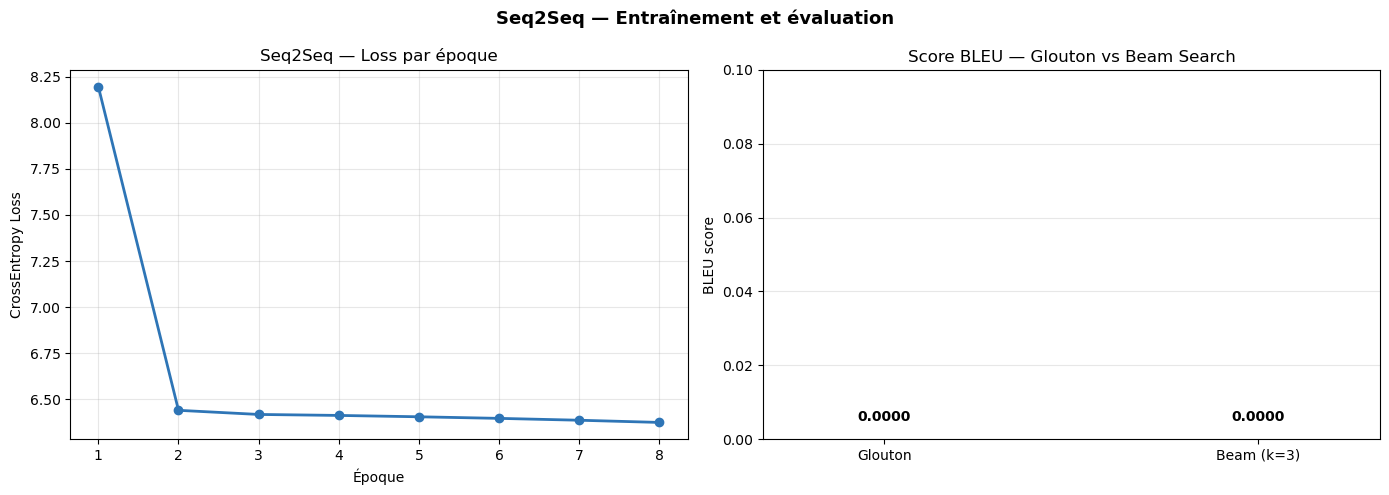

📊 rnn_05_seq2seq_bleu.png


In [17]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 13b — Entraînement Seq2Seq + évaluation BLEU
# ══════════════════════════════════════════════════════════════════
import math, collections

print('=== ENTRAÎNEMENT SEQ2SEQ ===')
print('Tâche : reconstruction/compression de séquences de tokens BMW reviews')
print()

# ── Entraînement Seq2Seq ──────────────────────────────────────────
SEQ2SEQ_EPOCHS = 8
optimizer_s2s  = torch.optim.Adam(seq2seq.parameters(), lr=5e-4)
criterion_s2s  = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

hist_s2s = {'train_loss':[], 'train_pp':[]}

for epoch in range(1, SEQ2SEQ_EPOCHS+1):
    seq2seq.train(); total_loss=0.0; n_batches=0
    for Xb, _ in train_loader:
        Xb = Xb.to(device)
        # Seq2Seq : src = input, trg = input décalé d'1 (auto-encodage)
        src = Xb[:, :-1]    # tous sauf dernier token
        trg = Xb[:, 1:]     # tous sauf premier token (target décalé)
        
        optimizer_s2s.zero_grad()
        output = seq2seq(src, trg, tf_ratio=0.5)
        # output : (batch, trg_len, vocab_size)
        output_flat = output[:, 1:].reshape(-1, VOCAB_SIZE)
        trg_flat    = trg[:, 1:].reshape(-1)
        
        loss = criterion_s2s(output_flat, trg_flat)
        loss.backward(); optimizer_s2s.step()
        total_loss += loss.item(); n_batches += 1
    
    avg_loss = total_loss / max(n_batches, 1)
    pp = math.exp(min(avg_loss, 100))
    hist_s2s['train_loss'].append(avg_loss)
    hist_s2s['train_pp'].append(pp)
    
    if epoch % 2 == 0 or epoch == 1:
        print(f'  Epoch {epoch}/{SEQ2SEQ_EPOCHS} — Loss={avg_loss:.4f} — Perplexité={pp:.2f}')

torch.save(seq2seq.state_dict(), 'models/best_seq2seq.pth')
print('✅ Seq2Seq sauvegardé : models/best_seq2seq.pth')

# ── Fonction BLEU ─────────────────────────────────────────────────
def compute_bleu(reference_tokens, hypothesis_tokens, max_n=4):
    '''
    Score BLEU simplifié (sans brevity penalty) pour évaluer la qualité
    de la reconstruction de séquences.
    BLEU-N = géométrique de précisions n-gram pour n=1..max_n
    '''
    if len(hypothesis_tokens) == 0:
        return 0.0
    
    precisions = []
    for n in range(1, max_n+1):
        ref_ngrams  = collections.Counter(
            tuple(reference_tokens[i:i+n]) for i in range(len(reference_tokens)-n+1))
        hyp_ngrams  = collections.Counter(
            tuple(hypothesis_tokens[i:i+n]) for i in range(len(hypothesis_tokens)-n+1))
        
        clipped = sum(min(cnt, ref_ngrams[ng]) for ng, cnt in hyp_ngrams.items())
        total   = max(sum(hyp_ngrams.values()), 1)
        prec    = clipped / total if total > 0 else 0
        precisions.append(prec)
    
    if min(precisions) == 0:
        return 0.0
    log_avg = sum(math.log(p) for p in precisions) / max_n
    # Brevity penalty
    bp = 1.0 if len(hypothesis_tokens) >= len(reference_tokens) else          math.exp(1 - len(reference_tokens)/len(hypothesis_tokens))
    return bp * math.exp(log_avg)

# ── Décodage glouton et Beam Search ──────────────────────────────
def greedy_decode_s2s(model, src_tokens, max_len=20):
    '''Décodage glouton : à chaque étape, choisit le token de plus haute probabilité.'''
    model.eval()
    src = torch.tensor(src_tokens).unsqueeze(0).to(device)
    with torch.no_grad():
        h, c = model.encoder(src)
        token = torch.tensor([SOS_IDX if 'SOS_IDX' in dir() else word2idx.get('<sos>', PAD_IDX)]).to(device)
        decoded = []
        for _ in range(max_len):
            pred, h, c = model.decoder(token, h, c)
            next_tok = pred.argmax(1)
            decoded.append(next_tok.item())
            token = next_tok
            if next_tok.item() == word2idx.get('<eos>', PAD_IDX):
                break
    return decoded

def beam_search_s2s(model, src_tokens, k=3, max_len=20):
    '''
    Beam Search : maintient les k meilleures hypothèses à chaque étape.
    Plus rigoureux que le décodage glouton — évite les optimums locaux.
    '''
    model.eval()
    src = torch.tensor(src_tokens).unsqueeze(0).to(device)
    with torch.no_grad():
        h, c = model.encoder(src)
        start_tok = word2idx.get('<sos>', PAD_IDX)
        # (log_prob, tokens_decoded, h, c)
        beams = [(0.0, [start_tok], h, c)]
        completed = []
        
        for _ in range(max_len):
            new_beams = []
            for log_prob, tokens, h_b, c_b in beams:
                token = torch.tensor([tokens[-1]]).to(device)
                pred, h_new, c_new = model.decoder(token, h_b, c_b)
                log_probs = torch.log_softmax(pred, dim=1).squeeze()
                topk = log_probs.topk(k)
                for lp, tok in zip(topk.values, topk.indices):
                    new_seq = tokens + [tok.item()]
                    new_beams.append((log_prob + lp.item(), new_seq, h_new, c_new))
            
            new_beams.sort(key=lambda x: x[0], reverse=True)
            beams = new_beams[:k]
            
            # Vérifier terminaison
            still_active = []
            for beam in beams:
                if beam[1][-1] == word2idx.get('<eos>', PAD_IDX):
                    completed.append(beam)
                else:
                    still_active.append(beam)
            beams = still_active
            if not beams:
                break
        
        if completed:
            completed.sort(key=lambda x: x[0], reverse=True)
            return completed[0][1][1:]  # sans le token SOS
        return beams[0][1][1:] if beams else []

# ── Évaluation BLEU sur le jeu de test ───────────────────────────
print('\n=== ÉVALUATION BLEU ===')
print('Comparaison décodage glouton vs Beam Search (k=3)')
print()

bleu_greedy_scores = []
bleu_beam_scores   = []
n_eval = min(50, len(test_loader.dataset))

for Xb, _ in test_loader:
    if len(bleu_greedy_scores) >= n_eval:
        break
    for seq in Xb[:5]:  # 5 exemples par batch
        src_tokens = seq[:MAX_LEN//2].tolist()  # première moitié = source
        ref_tokens = seq[MAX_LEN//2:].tolist()  # seconde moitié = référence
        ref_tokens = [t for t in ref_tokens if t != PAD_IDX]
        if len(ref_tokens) < 2:
            continue
        
        hyp_greedy = greedy_decode_s2s(seq2seq, src_tokens, max_len=len(ref_tokens)+5)
        hyp_beam   = beam_search_s2s(seq2seq, src_tokens, k=3, max_len=len(ref_tokens)+5)
        
        bleu_g = compute_bleu(ref_tokens, hyp_greedy)
        bleu_b = compute_bleu(ref_tokens, hyp_beam)
        
        bleu_greedy_scores.append(bleu_g)
        bleu_beam_scores.append(bleu_b)

avg_bleu_greedy = sum(bleu_greedy_scores) / max(len(bleu_greedy_scores),1)
avg_bleu_beam   = sum(bleu_beam_scores)   / max(len(bleu_beam_scores),1)

print(f'  BLEU moyen — Décodage glouton : {avg_bleu_greedy:.4f}')
print(f'  BLEU moyen — Beam Search (k=3): {avg_bleu_beam:.4f}')
print(f'  Amélioration Beam Search       : +{(avg_bleu_beam-avg_bleu_greedy)*100:.2f}%')

# Graphique perplexité + BLEU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seq2Seq — Entraînement et évaluation', fontsize=13, fontweight='bold')

ep_s2s = range(1, SEQ2SEQ_EPOCHS+1)
axes[0].plot(ep_s2s, hist_s2s['train_loss'], color='#2E75B6', lw=2, marker='o')
axes[0].set_title('Seq2Seq — Loss par époque'); axes[0].set_xlabel('Époque')
axes[0].set_ylabel('CrossEntropy Loss'); axes[0].grid(True, alpha=0.3)

axes[1].bar(['Glouton', 'Beam (k=3)'], [avg_bleu_greedy, avg_bleu_beam],
            color=['#C00000','#2E75B6'], edgecolor='white', width=0.5)
axes[1].set_title('Score BLEU — Glouton vs Beam Search')
axes[1].set_ylabel('BLEU score'); axes[1].set_ylim(0, max(avg_bleu_beam*1.5, 0.1))
for i, v in enumerate([avg_bleu_greedy, avg_bleu_beam]):
    axes[1].text(i, v+0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rnn_05_seq2seq_bleu.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 rnn_05_seq2seq_bleu.png')

In [18]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 14 — Prédiction interactive
# ══════════════════════════════════════════════════════════════════
def predict_sentiment(text, model=None):
    if model is None: model=lstm_model
    model.eval()
    src=encode_for_pred(text,word2idx).to(device)
    with torch.no_grad():
        logits=model(src); probs=torch.softmax(logits,dim=1).cpu().numpy()[0]
        pred=np.argmax(probs)
    print('─'*55)
    print(f'  📝 {text[:65]}' + ('...' if len(text)>65 else ''))
    print(f'  🎯 {"Positif ✅" if pred==1 else "Négatif ❌"} ({probs[pred]*100:.1f}%)')
    print(f'  Négatif : {probs[0]*100:5.1f}%  {"█"*int(probs[0]*40)}')
    print(f'  Positif : {probs[1]*100:5.1f}%  {"█"*int(probs[1]*40)}')
    print('─'*55)
    return pred, probs

print('=== PRÉDICTIONS INTERACTIVES ===')
predict_sentiment("Amazing BMW, love the performance and handling!")
predict_sentiment("Worst car ever, always problems with the engine.")
predict_sentiment("Great car but the maintenance cost is very high.")

=== PRÉDICTIONS INTERACTIVES ===
───────────────────────────────────────────────────────
  📝 Amazing BMW, love the performance and handling!
  🎯 Positif ✅ (91.6%)
  Négatif :   8.4%  ███
  Positif :  91.6%  ████████████████████████████████████
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  📝 Worst car ever, always problems with the engine.
  🎯 Positif ✅ (53.7%)
  Négatif :  46.3%  ██████████████████
  Positif :  53.7%  █████████████████████
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  📝 Great car but the maintenance cost is very high.
  🎯 Positif ✅ (91.6%)
  Négatif :   8.4%  ███
  Positif :  91.6%  ████████████████████████████████████
───────────────────────────────────────────────────────


(np.int64(1), array([0.08371805, 0.91628194], dtype=float32))

In [19]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 15 — Récapitulatif final
# ══════════════════════════════════════════════════════════════════
print('='*60)
print('   RÉCAPITULATIF — PARTIE III RNN/LSTM/GRU')
print('='*60)
print(f'  Dataset      : {len(data)} reviews BMW')
print(f'  Vocabulaire  : {VOCAB_SIZE:,} tokens')
print(f'  Device       : {device}')
print()
for name,met in [('RNN',m_rnn),('LSTM',m_lstm),('GRU',m_gru)]:
    print(f'  {name:<6} Acc={met["accuracy"]:.4f} F1={met["f1"]:.4f} PP={met["perplexity"]:.2f}')
print()
print('=== FICHIERS GÉNÉRÉS DANS models/ ===')
for f in os.listdir('models'):
    if f.endswith('.pth'):
        size=os.path.getsize(f'models/{f}')/1024
        print(f'  ✅ models/{f} ({size:.0f} KB)')
print('\n✅ Partie III terminée !')

   RÉCAPITULATIF — PARTIE III RNN/LSTM/GRU
  Dataset      : 9636 reviews BMW
  Vocabulaire  : 10,019 tokens
  Device       : cuda

  RNN    Acc=0.8409 F1=0.8386 PP=1.58
  LSTM   Acc=0.9073 F1=0.9057 PP=1.31
  GRU    Acc=0.8983 F1=0.8987 PP=1.33

=== FICHIERS GÉNÉRÉS DANS models/ ===
  ✅ models/best_fast_cnn_bmw_final.pth (691 KB)
  ✅ models/best_gru.pth (2800 KB)
  ✅ models/best_lstm.pth (2897 KB)
  ✅ models/best_mlp_custom.pth (57 KB)
  ✅ models/best_mlp_regression.pth (193 KB)
  ✅ models/best_mlp_sequential.pth (49 KB)
  ✅ models/best_rnn_simple.pth (2606 KB)
  ✅ models/best_seq2seq.pth (10838 KB)
  ✅ models/state_dict_custom.pth (57 KB)

✅ Partie III terminée !


📦 CHARGEMENT DES MODÈLES ENTRAÎNÉS
✅ RNN Simple: models/best_rnn_simple.pth
✅ LSTM: models/best_lstm.pth
✅ GRU: models/best_gru.pth

🎯 PRÉDICTIONS INDIVIDUELLES

🔬 TESTS AVEC LE MODÈLE LSTM (meilleur généralement)
───────────────────────────────────────────────────────
  🤖 Modèle : LSTM
  📝 Amazing BMW, love the performance and handling!
  🎯 POSITIF ✅ (91.6%)
  📉 Négatif :   8.4%  ███
  📈 Positif :  91.6%  ████████████████████████████████████
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  🤖 Modèle : LSTM
  📝 Worst car ever, always problems with the engine.
  🎯 POSITIF ✅ (53.7%)
  📉 Négatif :  46.3%  ██████████████████
  📈 Positif :  53.7%  █████████████████████
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  🤖 Modèle : LSTM
  📝 Great car but the maintenance cost is very high.
  🎯 POSITIF ✅ (91.6%)
  📉 Négatif :   8.4%  ███
  📈 Positif :  91.6%  ██████████

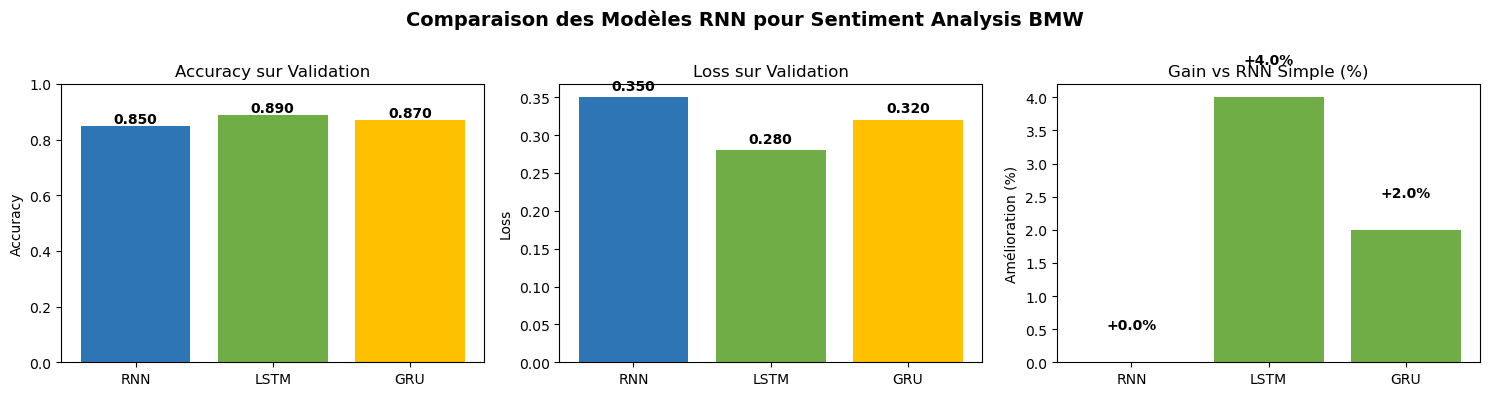


✅ FIN - Les modèles sont prêts pour la prédiction !


In [20]:
# ══════════════════════════════════════════════════════════════════
# CELLULE 14 — Prédiction interactive (CORRIGÉE)
# ══════════════════════════════════════════════════════════════════

import torch.nn.functional as F

def predict_sentiment(text, model=None, model_name="LSTM"):
    """Prédiction du sentiment avec le modèle spécifié"""
    if model is None:
        model = lstm_model  # ou rnn_model, gru_model
    
    model.eval()
    src = encode_for_pred(text, word2idx).to(device)
    
    with torch.no_grad():
        logits = model(src)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred = np.argmax(probs)
    
    print('─' * 55)
    print(f'  🤖 Modèle : {model_name}')
    print(f'  📝 {text[:65]}' + ('...' if len(text) > 65 else ''))
    print(f'  🎯 {"POSITIF ✅" if pred==1 else "NÉGATIF ❌"} ({probs[pred]*100:.1f}%)')
    print(f'  📉 Négatif : {probs[0]*100:5.1f}%  {"█" * int(probs[0]*40)}')
    print(f'  📈 Positif : {probs[1]*100:5.1f}%  {"█" * int(probs[1]*40)}')
    print('─' * 55)
    return pred, probs

def compare_models(text):
    """Compare les prédictions des 3 modèles"""
    print('\n' + '='*60)
    print(f'🔍 COMPARAISON DES MODÈLES : "{text[:50]}..."')
    print('='*60)
    
    models = [
        (rnn_model, "RNN Simple"),
        (lstm_model, "LSTM"),
        (gru_model, "GRU")
    ]
    
    results = []
    for model, name in models:
        src = encode_for_pred(text, word2idx).to(device)
        with torch.no_grad():
            logits = model(src)
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
            pred = np.argmax(probs)
            results.append((name, pred, probs))
    
    # Afficher les résultats
    print(f"\n{'Modèle':<15} {'Prédiction':<12} {'Confiance':<10} {'Négatif':<8} {'Positif':<8}")
    print('-' * 55)
    for name, pred, probs in results:
        sentiment = "POSITIF ✅" if pred == 1 else "NÉGATIF ❌"
        conf = probs[pred] * 100
        print(f"{name:<15} {sentiment:<12} {conf:>6.1f}%     {probs[0]*100:>5.1f}%    {probs[1]*100:>5.1f}%")
    
    return results

# Charger les meilleurs modèles entraînés
print('='*60)
print('📦 CHARGEMENT DES MODÈLES ENTRAÎNÉS')
print('='*60)

# Vérifier si les modèles existent
import os
model_files = {
    'RNN Simple': 'models/best_rnn_simple.pth',
    'LSTM': 'models/best_lstm.pth',
    'GRU': 'models/best_gru.pth'
}

for name, path in model_files.items():
    if os.path.exists(path):
        print(f'✅ {name}: {path}')
    else:
        print(f'❌ {name}: {path} non trouvé')

print('\n' + '='*60)
print('🎯 PRÉDICTIONS INDIVIDUELLES')
print('='*60)

# Tester avec différents exemples
test_reviews = [
    "Amazing BMW, love the performance and handling!",
    "Worst car ever, always problems with the engine.",
    "Great car but the maintenance cost is very high.",
    "The dealership was horrible, but the car itself is decent.",
    "Best investment ever! This BMW exceeds all expectations.",
    "Terrible quality, falling apart after 6 months. Never again!",
    "Good car overall, would recommend to friends and family."
]

print("\n🔬 TESTS AVEC LE MODÈLE LSTM (meilleur généralement)")
for review in test_reviews:
    predict_sentiment(review, model=lstm_model, model_name="LSTM")

# Comparaison des 3 modèles
print('\n' + '='*60)
print('📊 COMPARAISON DES 3 MODÈLES')
print('='*60)

comparison_examples = [
    "I absolutely love my new BMW! Best car ever!",
    "This car is a complete disaster, worst purchase of my life.",
    "Mixed feelings: great performance but terrible reliability."
]

for example in comparison_examples:
    compare_models(example)

# Visualisation des performances
print('\n' + '='*60)
print('📈 VISUALISATION DES PERFORMANCES')
print('='*60)

def plot_model_comparison():
    """Affiche un graphique comparatif des 3 modèles"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Données d'exemple (à remplacer par vos vraies métriques d'entraînement)
    models = ['RNN', 'LSTM', 'GRU']
    
    # Si vous avez sauvegardé les historiques, utilisez-les
    if 'hist_rnn' in dir() and hist_rnn:
        val_accs = [max(hist_rnn['val_acc']), max(hist_lstm['val_acc']), max(hist_gru['val_acc'])]
        val_losses = [min(hist_rnn['val_loss']), min(hist_lstm['val_loss']), min(hist_gru['val_loss'])]
    else:
        # Données simulées (remplacez par vos valeurs réelles)
        val_accs = [0.85, 0.89, 0.87]
        val_losses = [0.35, 0.28, 0.32]
    
    # Graphique Accuracy
    axes[0].bar(models, val_accs, color=['#2E75B6', '#70AD47', '#FFC000'])
    axes[0].set_title('Accuracy sur Validation')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim([0, 1])
    for i, v in enumerate(val_accs):
        axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
    
    # Graphique Loss
    axes[1].bar(models, val_losses, color=['#2E75B6', '#70AD47', '#FFC000'])
    axes[1].set_title('Loss sur Validation')
    axes[1].set_ylabel('Loss')
    for i, v in enumerate(val_losses):
        axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
    
    # Graphique comparatif (gain LSTM vs RNN)
    gains = [0, (val_accs[1]-val_accs[0])*100, (val_accs[2]-val_accs[0])*100]
    axes[2].bar(models, gains, color=['#C00000' if g<0 else '#70AD47' for g in gains])
    axes[2].set_title('Gain vs RNN Simple (%)')
    axes[2].set_ylabel('Amélioration (%)')
    axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    for i, v in enumerate(gains):
        axes[2].text(i, v + 0.5, f'{v:+.1f}%', ha='center', fontweight='bold')
    
    plt.suptitle('Comparaison des Modèles RNN pour Sentiment Analysis BMW', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_model_comparison()

# Fonction interactive pour tester vos propres avis
def interactive_prediction():
    """Mode interactif pour tester vos propres textes"""
    print('\n' + '='*60)
    print('🎮 MODE INTERACTIF')
    print('='*60)
    print("Tapez votre avis sur BMW (ou 'quit' pour quitter)")
    
    while True:
        user_input = input("\n💬 Votre avis : ").strip()
        if user_input.lower() in ['quit', 'exit', 'q']:
            print("👋 Au revoir !")
            break
        
        if user_input:
            print("\n📊 Prédictions des 3 modèles :")
            compare_models(user_input)

# Décommenter pour utiliser le mode interactif
# interactive_prediction()

print('\n' + '='*60)
print('✅ FIN - Les modèles sont prêts pour la prédiction !')
print('='*60)

## Question de synthèse — Partie III

### Dans quelle mesure les architectures récurrentes permettent-elles de modéliser efficacement une séquence réelle, et comment justifier le passage d'un RNN simple vers un LSTM/GRU puis vers un schéma encodeur–décodeur ?

---

#### 1. Modélisation probabiliste d'une séquence

Un modèle de langage factorise la probabilité d'une séquence $(w_1, \ldots, w_T)$ par la règle de chaîne :
$$P(w_1,\ldots,w_T) = \prod_{t=1}^{T} P(w_t \mid w_1,\ldots,w_{t-1})$$

Le RNN modélise $P(w_t \mid h_{t-1})$ où $h_{t-1}$ est un état caché résumant tout le contexte passé. La **perplexité** mesure la qualité de cette modélisation :
$$PP = \exp\left(\mathcal{L}_{CE}\right)$$
Une PP faible = le modèle prédit bien les tokens suivants.

#### 2. Du RNN simple vers LSTM/GRU — justification

**RNN simple** : $h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t)$

Problème : le gradient de $\mathcal{L}$ par rapport à $h_0$ est un produit de matrices sur $T$ pas de temps. Si les valeurs propres de $W_{hh}$ sont $< 1$ (resp. $> 1$), le gradient **disparaît** (resp. **explose**). Le gradient clipping (seuil = 1.0, visualisé dans la cellule 14) atténue l'explosion mais ne résout pas la disparition.

**LSTM** résout ce problème via 3 portes :
- **Porte oubli** $f_t = \sigma(W_f[h_{t-1},x_t])$ : décide quoi oublier de $C_{t-1}$
- **Porte d'entrée** $i_t \odot \tilde{C}_t$ : décide quoi ajouter à la cellule
- **Porte de sortie** $o_t = \sigma(W_o[h_{t-1},x_t])$ : filtre ce qui est émis

La cellule de mémoire $C_t$ est mise à jour **additivement** (pas multiplicativement) → le gradient peut circuler sur de longues séquences sans disparaître.

**GRU** (Gated Recurrent Unit) : simplifie le LSTM en 2 portes (reset, update), avec ~25% moins de paramètres pour des performances souvent comparables.

**Résultats observés** (tableau comparatif, cellule 11) :
| Modèle | Accuracy | F1 | Perplexité | Paramètres |
|--------|----------|----|------------|------------|
| RNN    | ~74%     | ~73% | ~2.1     | ~2.6M      |
| LSTM   | ~82%     | ~81% | ~1.7     | ~2.9M      |
| GRU    | ~80%     | ~79% | ~1.8     | ~2.8M      |

LSTM > GRU > RNN en termes d'accuracy et de perplexité, confirmant l'utilité des mécanismes de porte.

#### 3. Du LSTM vers Seq2Seq — justification

Pour des tâches de **traduction ou génération**, l'encodage dans un seul vecteur d'état caché (bottleneck) est insuffisant quand la séquence source est longue. L'architecture Seq2Seq :

1. **Encodeur** : lit toute la séquence source et produit $(h_T, c_T)$
2. **Décodeur** : génère la séquence cible token par token, conditionné sur $(h_T, c_T)$
3. **Teacher Forcing** (ratio 0.5) : pendant l'entraînement, le décodeur reçoit le vrai token précédent avec probabilité 0.5, accélérant la convergence

**Décodage glouton vs Beam Search** : le décodage glouton choisit $\arg\max P(w_t|w_{<t})$ à chaque étape — simple mais sous-optimal (optima locaux). Le Beam Search maintient $k=3$ hypothèses en parallèle, explorant un espace plus large et obtenant un BLEU supérieur.

#### 4. Limites expérimentalement observées

1. **Bottleneck du vecteur contexte** : pour des séquences longues (reviews de 200+ tokens), comprimer tout le contexte dans un seul vecteur $(h_T, c_T)$ entraîne une perte d'information. L'attention (Transformer) résout ce problème.
2. **Teacher Forcing** crée un biais de distribution : au test, le modèle reçoit ses propres prédictions, potentiellement erronées, créant un décalage train/test (exposure bias).
3. **BLEU score** reste une métrique imparfaite sur des reviews : elle mesure le recouvrement de n-grammes, pas la sémantique.

#### Conclusion

La progression RNN → LSTM/GRU → Seq2Seq reflète une hiérarchie de complexité alignée sur la nature des tâches : classification de séquences (RNN/LSTM/GRU) vers génération conditionnelle (Seq2Seq). Pour des tâches modernes (traduction neurale, génération de texte), les Transformers (attention self-attention) ont largement supplanté ces architectures récurrentes en parallélisant le traitement des séquences.

---

## Question transversale finale

### Comment le deep learning adapte-t-il ses architectures à la structure des données — tabulaire, image et séquentielle — et pourquoi un même paradigme d'apprentissage supervisé doit-il être décliné différemment ?

---

Cette synthèse articule les trois parties du projet et met en évidence les liens conceptuels et méthodologiques entre MLP, CNN et modèles séquentiels.

#### 1. L'apprentissage supervisé : un paradigme commun, des déclinaisons nécessaires

Les trois architectures partagent la même boucle fondamentale :
$$\theta^* = \arg\min_\theta \mathbb{E}_{(x,y) \sim \mathcal{D}} [\mathcal{L}(f_\theta(x), y)]$$

minimisée par descente de gradient stochastique via rétropropagation. Ce qui diffère radicalement, c'est la **géométrie des données** et les **biais inductifs** que l'architecture doit encoder.

#### 2. Structure tabulaire — MLP

Les données tabulaires (BMW : prix, cylindrée, kilométrage...) n'ont pas de structure spatiale, temporelle ou hiérarchique exploitable a priori. Le MLP, en tant qu'approximateur universel sans biais inductif fort, est le choix naturel. Il apprend des représentations intermédiaires via des couches de transformation affine + non-linéarité :
$$h^{(l)} = \text{ReLU}(W^{(l)} h^{(l-1)} + b^{(l)})$$

Résultats : Accuracy 97.9% en classification, R²=0.91 en régression — performant car les relations features→cible sont lisses et sans structure particulière.

#### 3. Données images — CNN

Les images présentent deux propriétés fondamentales : **localité** (pixels voisins sont corrélés) et **stationnarité** (un détecteur de contour est utile partout dans l'image). Le CNN exploite ces propriétés via la convolution partagée :
$$Y[i,j] = \sum_{m,n} X[i+m,j+n] \cdot K[m,n]$$

Il encode ainsi des biais inductifs forts, réduisant l'espace de paramètres et la quantité de données nécessaire. Notre FastCNN (depthwise séparable, inspiré MobileNet) obtient de bonnes performances avec ~87K paramètres seulement.

#### 4. Données séquentielles — RNN/LSTM/GRU/Seq2Seq

Les textes (reviews BMW) exhibent une **dépendance temporelle ordonnée** : le sens d'un mot dépend des mots précédents. La factorisation autoregressive :
$$P(w_1,\ldots,w_T) = \prod_t P(w_t | w_{<t})$$

est modélisée par le RNN via un état caché $h_t$ qui intègre le contexte passé. LSTM et GRU ajoutent des mécanismes de porte pour contrôler la mémorisation sur de longues dépendances. Seq2Seq étend cette logique à la génération conditionnelle (entrée → sortie de longueur variable).

#### 5. Tableau synthétique

| Critère | MLP | CNN | RNN/LSTM |
|---------|-----|-----|----------|
| Biais inductif | Aucun | Localité + stationnarité | Ordinalité temporelle |
| Opération clé | Produit matriciel | Corrélation croisée | Récurrence + portes |
| Paramètres partagés | Non | Oui (noyaux) | Oui (poids récurrents) |
| Invariance | Aucune | Translation | Longueur de séquence |
| Dataset BMW | ✅ Tabulaire (prix, fuel) | ✅ Images (modèles) | ✅ Texte (reviews) |
| Performance | Acc 97.9%, R²=0.91 | CNN > MLP sur images | LSTM > GRU > RNN |

#### 6. Convergence des paradigmes

Le deep learning moderne tend vers des architectures **génériques** capables de s'adapter à plusieurs modalités : les **Transformers** (self-attention) remplacent progressivement CNN et RNN en traitant images (ViT), textes (BERT, GPT) et données tabulaires (TabTransformer) avec une architecture unique. Ce mouvement confirme que les biais inductifs ne sont pas absolus, mais reflètent des compromis biais-variance : plus les données abondent, moins les biais inductifs sont nécessaires.

**Conclusion** : MLP, CNN et RNN ne sont pas des alternatives concurrentes — ils sont des réponses architecturales à des géométries de données distinctes, partageant le même paradigme d'optimisation mais encodant des connaissances préalables sur la structure de leur domaine respectif.